<a href="https://www.kaggle.com/code/kowshikahamedhimel/final-year-project-bangla-static-signs-detection?scriptVersionId=284277375" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!python --version

Python 3.11.13


In [2]:
import torch
torch.__version__

'2.6.0+cu124'

In [3]:
cd /kaggle/working/


/kaggle/working


In [4]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device # select gpu from edit -> notebook settings ->gpu

'cuda'

In [6]:
# Setup directory paths to train and test images
train_dir = '/kaggle/input/vit_data_and_.pyfile/tensorflow2/default/1/VIT_Data_and_.pyFile_For_Bangla_Static_Sign/custom_dataset/Train'
test_dir = '/kaggle/input/vit_data_and_.pyfile/tensorflow2/default/1/VIT_Data_and_.pyFile_For_Bangla_Static_Sign/custom_dataset/Test'

In [7]:
#  Create Datasets and DataLoaders

import os

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

NUM_WORKERS = os.cpu_count()

def create_dataloaders(
    train_dir: str,
    test_dir: str,
    transform: transforms.Compose,
    batch_size: int,
    num_workers: int=NUM_WORKERS
):

  # Use ImageFolder to create dataset(s)
  train_data = datasets.ImageFolder(train_dir, transform=transform)
  test_data = datasets.ImageFolder(test_dir, transform=transform)

  # Get class names
  class_names = train_data.classes

  # Turn images into data loaders
  train_dataloader = DataLoader(
      train_data,
      batch_size=batch_size,
      shuffle=True,
      num_workers=num_workers,
      pin_memory=True,
  )
  test_dataloader = DataLoader(
      test_data,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      pin_memory=True,
  )

  return train_dataloader, test_dataloader, class_names

In [8]:
# Create image size
IMG_SIZE = 224

# Create transform pipeline manually
manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])  # normalize to [-1, 1]
])

print(f"Manually created transforms: {manual_transforms}")

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)


In [9]:
# Set the batch size
BATCH_SIZE = 32

# Create data loaders
train_dataloader, test_dataloader, class_names = create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms,
    batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names



(<torch.utils.data.dataloader.DataLoader at 0x780b0ad27d10>,
 ['01. Aaj',
  '02. Soptaho',
  '03. Kosom',
  '04. Potaka',
  '05. Rajdhani',
  '06. Girja',
  '07. Tia pakhi',
  '08. Grissokal',
  '09. Joma',
  '10. Sonchoy',
  '11. Greftar',
  '12. Jel',
  '13. Shanti',
  '14. Sotorko kora',
  '15. Camera',
  '16. Kanchi',
  '17. Biman',
  '18. Ukil',
  '19. Kuli',
  '20. Koshadhokkho',
  '21. Chakuri',
  '22. Napit',
  '23. Sovapoti',
  '24. Kripon',
  '25. Durgondho',
  '26. Puru',
  '27. Boka',
  '28. Bonduk',
  '29. Bari',
  '30. Bondhu',
  '31. Private',
  '32. Obak',
  '33. Onurodh',
  '34. Chamra',
  '35. Prosrab',
  '36. Chup',
  '37. Kichu',
  '38. Nam',
  '39. Dukkho',
  '40. Shokaboho'])

torch.Size([3, 224, 224]) tensor(18)


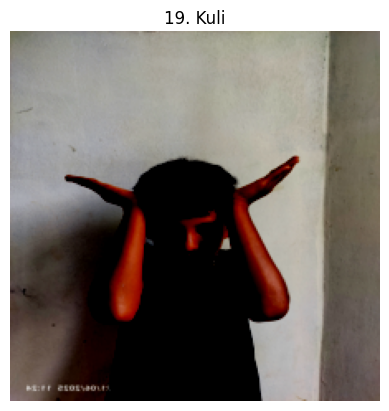

In [10]:
# Let's visualize a image in order to know if data is loaded properly or not

# Get a batch of images
image_batch, label_batch = next(iter(train_dataloader))

# Get a single image from the batch
image, label = image_batch[0], label_batch[0]

# View the batch shapes
print(image.shape, label)

# Plot image with matplotlib
plt.imshow(image.permute(2, 1, 0)) # rearrange image dimensions to suit matplotlib [color_channels, height, width] -> [height, width, color_channels]
plt.title(class_names[label])
plt.axis(False);

In [11]:
import sys
sys.path.append("/kaggle/input/vit02/tensorflow2/default/1")

In [12]:
from VIT_Data_For_Bangla_Static_Sign import vit_transformer_module
from VIT_Data_For_Bangla_Static_Sign.vit_transformer_module import PatchEmbedding, MultiheadSelfAttentionBlock, MLPBlock, TransformerEncoderBlock, ViT
VIT_Data_and_.pyFile_For_Bangla_Static_Sign

ModuleNotFoundError: No module named 'VIT_Data_and_'

In [ ]:
# Train our MOdel
# Create an instance of ViT with the number of classes we're working with
from torchvision.models import vit_b_16

# Load pretrained ViT
vit = vit_b_16(pretrained=True)

# Replace the classification head for our number of classes
vit.heads = nn.Linear(vit.heads.head.in_features, len(class_names))

# Move model to GPU if available
vit = vit.to(device)




# Setup the optimizer to optimize our ViT model parameters using hyperparameters from the ViT paper
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=3e-5, # Base LR from Table 3 for ViT-* ImageNet-1k
                             betas=(0.9, 0.999), # default values but also mentioned in ViT paper section 4.1 (Training & Fine-tuning)
                             weight_decay=1e-4) # from the ViT paper section 4.1 (Training & Fine-tuning) and Table 3 for ViT-* ImageNet-1k

# Setup the loss function for multi-class classification
loss_fn = torch.nn.CrossEntropyLoss()


from VIT_Data_For_Bangla_Static_Sign import  engine
# Train the model and save the training results to a dictionary
results = engine.train(model=vit,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=25,
                       device=device)

# Save the trained model's state_dict
torch.save(vit.state_dict(), '/kaggle/working/vit_trained_model_02.pth')


In [ ]:
# To check out our ViT model's loss curves, we can use the plot_loss_curves function from helper_functions.py
from VIT_Data_For_Bangla_Static_Sign.helper_functions import plot_loss_curves


# Plot our ViT model's loss curves
plot_loss_curves(results)

# Prob on Test Image

In [ ]:
# Inference using trained model
import requests

# Import function to make predictions on images and plot them
from VIT_Data_For_Bangla_Static_Sign.helper_functions import pred_and_plot_image

# Setup custom image path
custom_image_path = "/kaggle/input/vit_data_and_.pyfile/tensorflow2/default/1/VIT_Data_and_.pyFile_For_Bangla_Static_Sign/custom_dataset/Test/01. Aaj/U33S01.jpg"

# Predict on custom image
pred_and_plot_image(model=vit,
                    image_path=custom_image_path,
                    class_names=class_names)

In [ ]:
# Inference using trained model
import requests

# Import function to make predictions on images and plot them
from VIT_Data_For_Bangla_Static_Sign.helper_functions import pred_and_plot_image

# Setup custom image path
custom_image_path = "/kaggle/input/vit_data_and_.pyfile/tensorflow2/default/1/VIT_Data_and_.pyFile_For_Bangla_Static_Sign/custom_dataset/Test/02. Soptaho/U34S02.jpg"

# Predict on custom image
pred_and_plot_image(model=vit,
                    image_path=custom_image_path,
                    class_names=class_names)

In [ ]:
# Inference using trained model
import requests

# Import function to make predictions on images and plot them
from VIT_Data_For_Bangla_Static_Sign.helper_functions import pred_and_plot_image

# Setup custom image path
custom_image_path = "/kaggle/input/vit_data_and_.pyfile/tensorflow2/default/1/VIT_Data_and_.pyFile_For_Bangla_Static_Sign/custom_dataset/Test/03. Kosom/U35S03.jpg"

# Predict on custom image
pred_and_plot_image(model=vit,
                    image_path=custom_image_path,
                    class_names=class_names)

In [ ]:
# Inference using trained model
import requests

# Import function to make predictions on images and plot them
from VIT_Data_For_Bangla_Static_Sign.helper_functions import pred_and_plot_image

# Setup custom image path
custom_image_path = "/kaggle/input/vit_data_and_.pyfile/tensorflow2/default/1/VIT_Data_and_.pyFile_For_Bangla_Static_Sign/custom_dataset/Test/04. Potaka/U36S04.jpg.jpg"

# Predict on custom image
pred_and_plot_image(model=vit,
                    image_path=custom_image_path,
                    class_names=class_names)

In [ ]:
# Inference using trained model
import requests

# Import function to make predictions on images and plot them
from VIT_Data_For_Bangla_Static_Sign.helper_functions import pred_and_plot_image

# Setup custom image path
custom_image_path = "/kaggle/input/vit_data_and_.pyfile/tensorflow2/default/1/VIT_Data_and_.pyFile_For_Bangla_Static_Sign/custom_dataset/Test/05. Rajdhani/U37S05.jpg"

# Predict on custom image
pred_and_plot_image(model=vit,
                    image_path=custom_image_path,
                    class_names=class_names)

# Prob on Train Image

In [ ]:
# Inference using trained model
import requests

# Import function to make predictions on images and plot them
from VIT_Data_For_Bangla_Static_Sign.helper_functions import pred_and_plot_image

# Setup custom image path
custom_image_path = "/kaggle/input/vit_data_and_.pyfile/tensorflow2/default/1/VIT_Data_and_.pyFile_For_Bangla_Static_Sign/custom_dataset/Train/30. Bondhu/U01S30.jpg"

# Predict on custom image
pred_and_plot_image(model=vit,
                    image_path=custom_image_path,
                    class_names=class_names)

In [ ]:
# Inference using trained model
import requests

# Import function to make predictions on images and plot them
from VIT_Data_For_Bangla_Static_Sign.helper_functions import pred_and_plot_image

# Setup custom image path
custom_image_path = "/kaggle/input/vit_data_and_.pyfile/tensorflow2/default/1/VIT_Data_and_.pyFile_For_Bangla_Static_Sign/custom_dataset/Train/29. Bari/U02S29.jpg"

# Predict on custom image
pred_and_plot_image(model=vit,
                    image_path=custom_image_path,
                    class_names=class_names)

In [ ]:
# Inference using trained model
import requests

# Import function to make predictions on images and plot them
from VIT_Data_For_Bangla_Static_Sign.helper_functions import pred_and_plot_image

# Setup custom image path
custom_image_path = "/kaggle/input/vit_data_and_.pyfile/tensorflow2/default/1/VIT_Data_and_.pyFile_For_Bangla_Static_Sign/custom_dataset/Train/28. Bonduk/U03S28.jpg"

# Predict on custom image
pred_and_plot_image(model=vit,
                    image_path=custom_image_path,
                    class_names=class_names)

In [ ]:
# Inference using trained model
import requests

# Import function to make predictions on images and plot them
from VIT_Data_For_Bangla_Static_Sign.helper_functions import pred_and_plot_image

# Setup custom image path
custom_image_path = "/kaggle/input/vit_data_and_.pyfile/tensorflow2/default/1/VIT_Data_and_.pyFile_For_Bangla_Static_Sign/custom_dataset/Train/27. Boka/U04S27.jpg"

# Predict on custom image
pred_and_plot_image(model=vit,
                    image_path=custom_image_path,
                    class_names=class_names)

In [ ]:
# Inference using trained model
import requests

# Import function to make predictions on images and plot them
from VIT_Data_For_Bangla_Static_Sign.helper_functions import pred_and_plot_image

# Setup custom image path
custom_image_path = "/kaggle/input/vit_data_and_.pyfile/tensorflow2/default/1/VIT_Data_and_.pyFile_For_Bangla_Static_Sign/custom_dataset/Train/26. Puru/U05S26.jpg"

# Predict on custom image
pred_and_plot_image(model=vit,
                    image_path=custom_image_path,
                    class_names=class_names)